In [17]:
# Add project root to path and enable auto-reload
import sys
sys.path.insert(0, '../..')

# Auto-reload modules before executing each cell
%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
from itertools import product
from tqdm import tqdm

from xgboost import XGBClassifier, XGBRegressor, DMatrix
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, make_scorer
from sklearn.utils.class_weight import compute_sample_weight
from grid_intelligence.logic import preprocessor

import optuna
import shap


## Loading data

In [57]:
# Load data (interaction features now generated in preprocessor.py)

df_model = preprocessor.generate_features(nrows=50000)

df_model = df_model.iloc[-60000:]
df_model["target_288"] = df_model["price"].shift(-288)
#split_idx = 27000

threshold_pos = 150
threshold_neg = 10

df_model["regime"] = 0  # normal
df_model.loc[df_model["price"] > threshold_pos, "regime"] = 1   # positive spike
df_model.loc[df_model["price"] < threshold_neg, "regime"] = 2  # negative spike

df_model = df_model.dropna().reset_index(drop=True)
# train = df_model.iloc[:split_idx]
# test = df_model.iloc[split_idx:]

# columns_to_drop = ["price", "target_288", "regime"]

# X_train = train.drop(columns=columns_to_drop)
# y_train = train["target_288"]
# y_regime_train = train["regime"]

# X_test = test.drop(columns=columns_to_drop)
# y_test = test["target_288"]
# y_regime_test = test["regime"]

# print(f"Features: {len(X_train.columns)}")
# print(f"Shape - X_train: {X_train.shape}, X_test: {X_test.shape}")


/Users/laurenzpfleiderer/code/xucenying/grid-intelligence/notebooks/laurenz/../../grid_intelligence/logic/data.py:95: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns, UTC] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  df["is_holiday"] = df[datetime_col].dt.floor("D").isin(de_holidays)
/Users/laurenzpfleiderer/code/xucenying/grid-intelligence/notebooks/laurenz/../../grid_intelligence/logic/data.py:124: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns, UTC] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  df['is_holiday_288'] = future_timestamp.dt.floor("D").isin(de_holidays).astype(int)


### Picking time frame

In [58]:
df_model['datetime_utc'].min()

Timestamp('2024-11-30 14:45:00+0000', tz='UTC')

In [59]:
start_date = "2025-02-01 00:00:00"
end_date  = "2026-02-01 00:00:00"
df_model['datetime_utc'] =  pd.to_datetime(df_model['datetime_utc'], format="%Y-%m-%d %H:%M:%S")

In [60]:
model_12m = df_model[(df_model['datetime_utc'] >= start_date) & (df_model['datetime_utc'] <= end_date)]

In [61]:
print(f"length: {len(model_12m)}; start: {model_12m['datetime_utc'].min()}, end: {model_12m['datetime_utc'].max()}")

length: 34368; start: 2025-02-01 00:00:00+00:00, end: 2026-02-01 00:00:00+00:00


In [68]:
# Last 3 days = 288 timesteps
forecast_horizon = 96

train = model_12m.iloc[:-forecast_horizon]
test = model_12m.iloc[-forecast_horizon:]

columns_to_drop = ["price", "target_288", "regime", "datetime_utc"]

X_train = train.drop(columns=columns_to_drop)
y_train = train["target_288"]
y_regime_train = train["regime"]

X_test = test.drop(columns=columns_to_drop)
y_test = test["target_288"]
y_regime_test = test["regime"]

print(f"Features: {len(X_train.columns)}")
print(f"Shape - X_train: {X_train.shape}, X_test: {X_test.shape}")

Features: 165
Shape - X_train: (34272, 165), X_test: (96, 165)


## Model train & shaply

In [10]:
from xgboost import XGBRegressor
from sklearn.utils.class_weight import compute_sample_weight

# ── 1. Regime Classifier ──────────────────────────────────────────────────────
weights = compute_sample_weight(class_weight="balanced", y=y_regime_train)
clf = XGBClassifier(objective="multi:softprob", num_class=3)
clf.fit(X_train, y_regime_train, sample_weight=weights)

# ── 2. Regime-specific XGBoost Regressors ─────────────────────────────────────
xgb_params = dict(
    n_estimators=300, learning_rate=0.01, max_depth=6,
    subsample=1.0, colsample_bytree=0.7, random_state=42,
    reg_lambda=5, reg_alpha=0.1, gamma=0
)
model_normal = XGBRegressor(**xgb_params)
model_pos    = XGBRegressor(**xgb_params)
model_neg    = XGBRegressor(**xgb_params)

# Train only on recent data for positive spikes (last ~24k samples)
recent_mask = X_train.index > (len(X_train) - 24000)
model_normal.fit(X_train[y_regime_train == 0], y_train[y_regime_train == 0])
model_pos.fit(X_train[(y_regime_train == 1) & recent_mask], y_train[(y_regime_train == 1) & recent_mask])
model_neg.fit(X_train[y_regime_train == 2], y_train[y_regime_train == 2])


# ── 3. Regime-blended predictions with GARCH amplitude correction ─────────────
probs    = clf.predict_proba(X_test)
p_normal = probs[:, 0]
p_pos    = probs[:, 1]
p_neg    = probs[:, 2]

y_pred_soft = (
    p_neg    * model_neg.predict(X_test)    * 0.85 +
    p_normal * model_normal.predict(X_test)  +
    p_pos    * model_pos.predict(X_test)    * 0.9
)

# ── 4. Evaluation & Visualization ─────────────────────────────────────────────
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae  = mean_absolute_error(y_test, y_pred_soft)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_soft))
print(f"\n=== PRODUCTION-REALISTIC PREDICTIONS (no lookahead) ===")
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

# Regime-specific MAE breakdown
normal_mask = y_regime_test == 0
pos_spike_mask = y_regime_test == 1
neg_spike_mask = y_regime_test == 2
spike_mask = (y_regime_test == 1) | (y_regime_test == 2)

mae_normal = mean_absolute_error(y_test[normal_mask], y_pred_soft[normal_mask]) if normal_mask.sum() > 0 else 0
mae_pos_spike = mean_absolute_error(y_test[pos_spike_mask], y_pred_soft[pos_spike_mask]) if pos_spike_mask.sum() > 0 else 0
mae_neg_spike = mean_absolute_error(y_test[neg_spike_mask], y_pred_soft[neg_spike_mask]) if neg_spike_mask.sum() > 0 else 0
mae_spike = mean_absolute_error(y_test[spike_mask], y_pred_soft[spike_mask]) if spike_mask.sum() > 0 else 0

print(f"\n=== MAE by Regime ===")
print(f"Normal (regime=0):    {mae_normal:.4f}  ({normal_mask.sum()} samples)")
print(f"Pos Spike (regime=1): {mae_pos_spike:.4f}  ({pos_spike_mask.sum()} samples)")
print(f"Neg Spike (regime=2): {mae_neg_spike:.4f}  ({neg_spike_mask.sum()} samples)")
print(f"All Spikes (1+2):     {mae_spike:.4f}  ({spike_mask.sum()} samples)")

# # Visualization
# fig, axes = plt.subplots(1, 1, figsize=(15, 8), sharex=False)
# axes.plot(y_test[-5000:].values, label="Actual", alpha=0.8)
# axes.plot(y_pred_soft[-5000:], label="Predicted (production approach)", alpha=0.8)
# axes.legend()
# axes.set_title("Electricity Price Prediction - Production-Realistic (no lookahead)")
# axes.set_ylabel("Price (EUR/MWh)")


# plt.tight_layout()
# plt.show()



=== PRODUCTION-REALISTIC PREDICTIONS (no lookahead) ===
MAE:  17.4647
RMSE: 21.5433

=== MAE by Regime ===
Normal (regime=0):    18.9720  (249 samples)
Pos Spike (regime=1): 7.8411  (39 samples)
Neg Spike (regime=2): 0.0000  (0 samples)
All Spikes (1+2):     7.8411  (39 samples)


### Sharply

In [54]:
import shap
from xgboost import DMatrix

# 1. Convert your data to DMatrix
dmatrix = DMatrix(X_train)

# 2. Get SHAP values from XGBoost directly
shap_values = model_normal.get_booster().predict(dmatrix, pred_contribs=True)

# 3. Remove last column (this is the bias term)
shap_values = shap_values[:, :-1]

# 4. Plot
shap.summary_plot(shap_values, X_train)
shap.summary_plot(shap_values, X_train, plot_type="bar")

NameError: name 'model_normal' is not defined

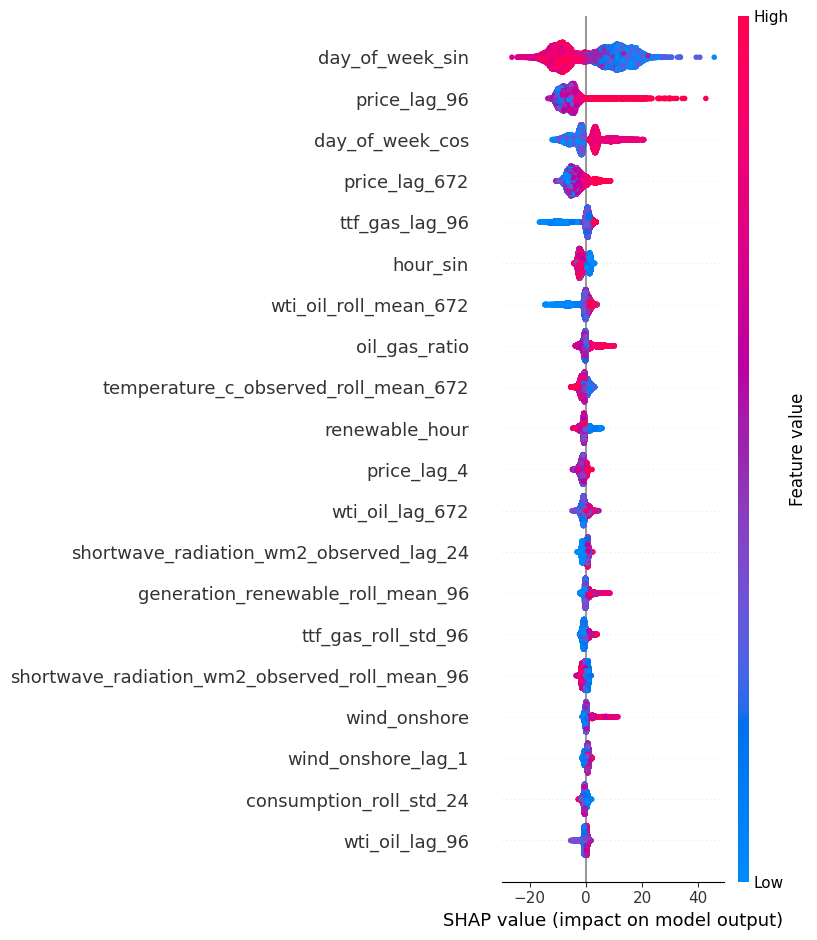

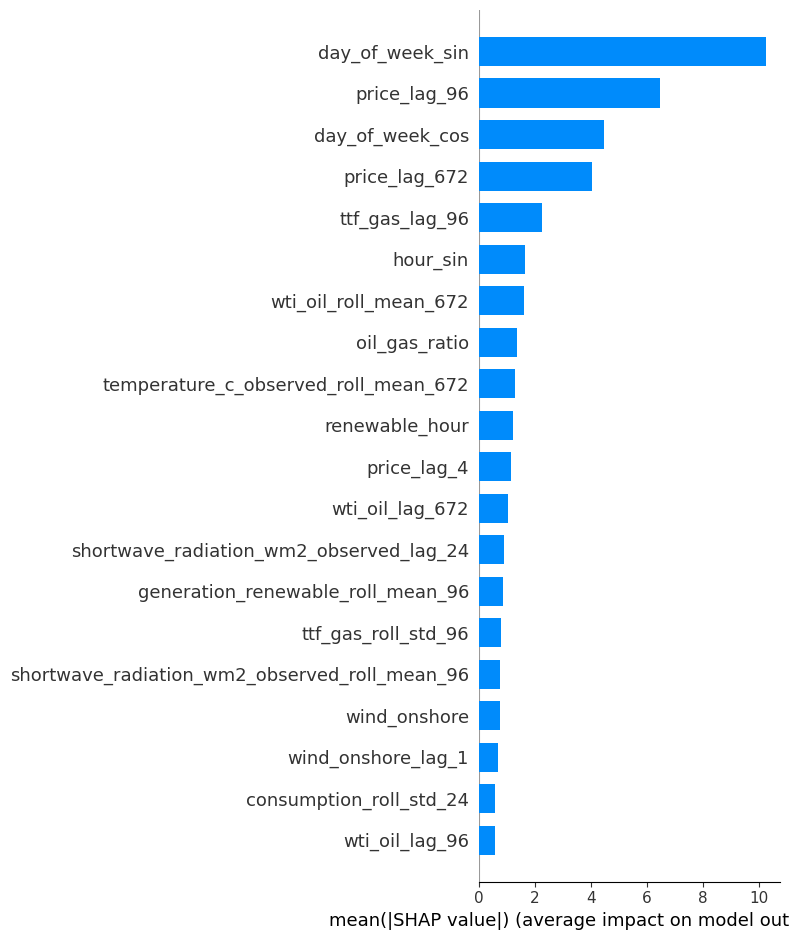

In [13]:
# 1. Convert your data to DMatrix
dmatrix = DMatrix(X_train)

# 2. Get SHAP values from XGBoost directly
shap_values = model_pos.get_booster().predict(dmatrix, pred_contribs=True)

# 3. Remove last column (this is the bias term)
shap_values = shap_values[:, :-1]

# 4. Plot
shap.summary_plot(shap_values, X_train)
shap.summary_plot(shap_values, X_train, plot_type="bar")

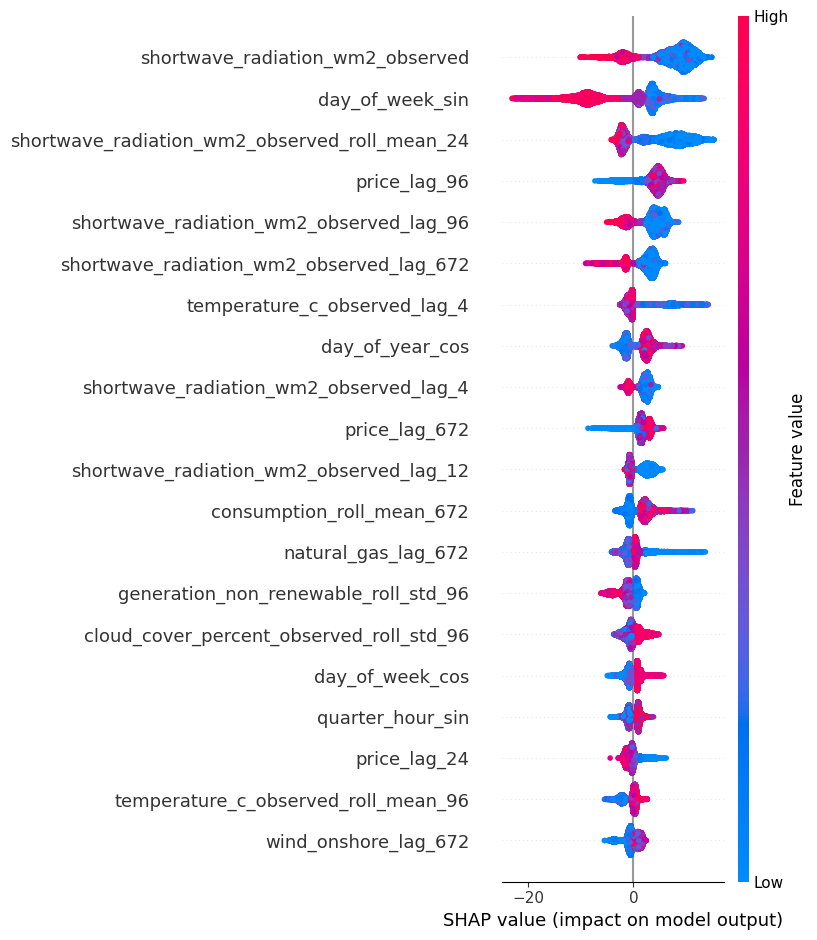

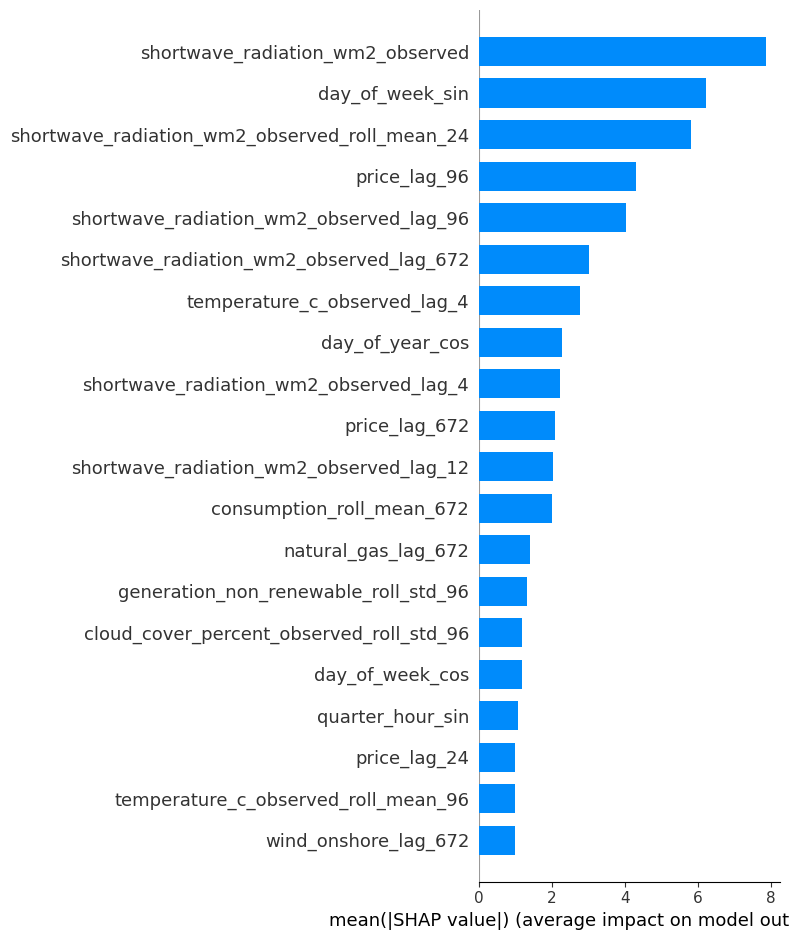

In [14]:
# 1. Convert your data to DMatrix
dmatrix = DMatrix(X_train)

# 2. Get SHAP values from XGBoost directly
shap_values = model_neg.get_booster().predict(dmatrix, pred_contribs=True)

# 3. Remove last column (this is the bias term)
shap_values = shap_values[:, :-1]

# 4. Plot
shap.summary_plot(shap_values, X_train)
shap.summary_plot(shap_values, X_train, plot_type="bar")

## Model improvement: Grid Search

In [ ]:
import numpy as np
import pandas as pd
from xgboost import XGBClassifier, XGBRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error
from sklearn.utils.class_weight import compute_sample_weight
import random
from itertools import product
from tqdm import tqdm

# ---------------------------
# 1. Prepare data
# ---------------------------

target = "target_288"

drop_cols = [
    "datetime_utc",
    "price",
    target
]

X = model_12m.drop(columns=drop_cols)
y = model_12m[target]

# assume regime labels already exist in model_12m
y_regime = model_12m["regime"]  # <- must exist (0=normal,1=pos,2=neg)

tscv = TimeSeriesSplit(n_splits=5)

# ---------------------------
# 2. Hyperparameter space
# ---------------------------

param_space = {
    "n_estimators": [200, 300, 500, 800],
    "max_depth": [3, 4, 6, 8, 10],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.7, 0.85, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "gamma": [0, 0.1, 0.3],
    "reg_alpha": [0, 0.1, 1],
    "reg_lambda": [1, 3, 5, 10]
}

def sample_params():
    return {k: random.choice(v) for k, v in param_space.items()}

# ---------------------------
# 3. Evaluation function
# ---------------------------

def evaluate_model(params):

    maes = []

    for train_idx, test_idx in tscv.split(X):

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        r_train = y_regime.iloc[train_idx]

        # ---- classifier ----
        weights = compute_sample_weight(class_weight="balanced", y=r_train)

        clf = XGBClassifier(
            objective="multi:softprob",
            num_class=3,
            n_estimators=200,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.9,
            colsample_bytree=0.9,
            random_state=42
        )

        clf.fit(X_train, r_train, sample_weight=weights)

        # ---- regressors per regime ----
        model_normal = XGBRegressor(**params, random_state=42)
        model_pos    = XGBRegressor(**params, random_state=42)
        model_neg    = XGBRegressor(**params, random_state=42)

        # masks
        recent_mask = X_train.index > (len(X_train) - 24000)

        model_normal.fit(X_train[r_train == 0], y_train[r_train == 0])

        if ((r_train == 1) & recent_mask).sum() > 50:
            model_pos.fit(X_train[(r_train == 1) & recent_mask],
                          y_train[(r_train == 1) & recent_mask])
        else:
            model_pos.fit(X_train[r_train == 1], y_train[r_train == 1])

        model_neg.fit(X_train[r_train == 2], y_train[r_train == 2])

        # ---- predictions ----
        probs = clf.predict_proba(X_test)

        p0, p1, p2 = probs[:, 0], probs[:, 1], probs[:, 2]

        pred = (
            p0 * model_normal.predict(X_test) +
            p1 * model_pos.predict(X_test) * 0.9 +
            p2 * model_neg.predict(X_test) * 0.85
        )

        maes.append(mean_absolute_error(y_test, pred))

    return np.mean(maes)

# ---------------------------
# 4. Random Search Loop
# ---------------------------

N_ITER = 20  # increase to 50–100 for better results

best_score = np.inf
best_params = None

for i in tqdm(range(N_ITER)):

    params = sample_params()

    score = evaluate_model(params)

    print(f"Iter {i+1}/{N_ITER} | MAE: {score:.5f}")

    if score < best_score:
        best_score = score
        best_params = params

# ---------------------------
# 5. Results
# ---------------------------

print("\nBEST RESULT")
print("MAE:", best_score)
print("Params:", best_params)

  5%|▌         | 1/20 [01:21<25:40, 81.06s/it]

Iter 1/20 | MAE: 33.30241


 10%|█         | 2/20 [02:01<17:05, 56.98s/it]

Iter 2/20 | MAE: 32.11454


 15%|█▌        | 3/20 [02:31<12:44, 44.99s/it]

...

Iter 5/20 | MAE: 33.61404


 30%|███       | 6/20 [04:05<08:17, 35.55s/it]

Iter 6/20 | MAE: 36.86290


 30%|███       | 6/20 [04:44<11:03, 47.38s/it]


KeyboardInterrupt: 

In [48]:
!pip install optuna

In [ ]:
#OPTUNA
import optuna

# ---------------------------
# 1. Prepare data
# ---------------------------

target = "target_288"

drop_cols = [
    "datetime_utc",
    "price",
    target
]

X = model_12m.drop(columns=drop_cols)
y = model_12m[target]

# assume regime labels already exist in model_12m
y_regime = model_12m["regime"]  # <- must exist (0=normal,1=pos,2=neg)

tscv = TimeSeriesSplit(n_splits=5)

# ---------------------------
# 2. Optuna objective
# ---------------------------

def objective(trial):

    # ---- shared regressor params ----
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 800),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "subsample": trial.suggest_float("subsample", 0.7, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "gamma": trial.suggest_float("gamma", 0.0, 0.3),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 1.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 1.0, 10.0),
        "random_state": 42,
        "tree_method": "hist"
    }

    # blending weights also tuned
    w_pos = trial.suggest_float("w_pos", 0.7, 1.0)
    w_neg = trial.suggest_float("w_neg", 0.7, 1.0)

    maes = []

    for train_idx, test_idx in tscv.split(X):

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        r_train = y_regime.iloc[train_idx]

        # ---- classifier ----
        weights = compute_sample_weight(class_weight="balanced", y=r_train)

        clf = XGBClassifier(
            objective="multi:softprob",
            num_class=3,
            n_estimators=200,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.9,
            colsample_bytree=0.9,
            random_state=42,
            tree_method="hist"
        )

        clf.fit(X_train, r_train, sample_weight=weights)

        # ---- regressors ----

        model_normal = XGBRegressor(**params)
        model_pos    = XGBRegressor(**params)
        model_neg    = XGBRegressor(**params)

        # masks
        recent_mask = X_train.index > (len(X_train) - 24000)

        model_normal.fit(X_train[r_train == 0], y_train[r_train == 0])

        if ((r_train == 1) & recent_mask).sum() > 50:
            model_pos.fit(X_train[(r_train == 1) & recent_mask],
                          y_train[(r_train == 1) & recent_mask])
        else:
            model_pos.fit(X_train[r_train == 1], y_train[r_train == 1])

        model_neg.fit(X_train[r_train == 2], y_train[r_train == 2])

        # ---- predictions ----
        probs = clf.predict_proba(X_test)

        p0, p1, p2 = probs[:, 0], probs[:, 1], probs[:, 2]

        pred = (
            p0 * model_normal.predict(X_test) +
            p1 * model_pos.predict(X_test) * w_pos +
            p2 * model_neg.predict(X_test) * w_neg
        )

        maes.append(mean_absolute_error(y_test, pred))

    return np.mean(maes)

# ---------------------------
# 3. Run Optuna
# ---------------------------


study = optuna.create_study(direction="minimize")

study.optimize(objective, n_trials=50, n_jobs=-1, show_progress_bar=True)  # increase to 100+



# ---------------------------
# 4. Results
# ---------------------------

print("\nBest MAE:", study.best_value)
print("\nBest Params:")
for k, v in study.best_params.items():
    print(f"{k}: {v}")

[I 2026-04-27 16:39:49,211] A new study created in memory with name: no-name-ea85d03a-04e5-4365-adb9-4b69798a9f76
Best trial: 7. Best value: 27.4667:   2%|▏         | 1/50 [01:28<1:12:32, 88.83s/it]

[I 2026-04-27 16:41:18,033] Trial 7 finished with value: 27.466745426081893 and parameters: {'n_estimators': 236, 'max_depth': 3, 'learning_rate': 0.013581196355935628, 'subsample': 0.8795034680663409, 'colsample_bytree': 0.8339719062338209, 'gamma': 0.06902629872338858, 'reg_alpha': 0.3157966317946941, 'reg_lambda': 7.263922752582223, 'w_pos': 0.9169768172668621, 'w_neg': 0.9466079173259309}. Best is trial 7 with value: 27.466745426081893.


Best trial: 7. Best value: 27.4667:   4%|▍         | 2/50 [02:12<49:38, 62.05s/it]  

[I 2026-04-27 16:42:01,244] Trial 4 finished with value: 27.628088584284193 and parameters: {'n_estimators': 307, 'max_depth': 4, 'learning_rate': 0.015242163836816595, 'subsample': 0.7463548631049488, 'colsample_bytree': 0.6292853092094347, 'gamma': 0.27372208299277356, 'reg_alpha': 0.41325187393422746, 'reg_lambda': 4.8491450705199615, 'w_pos': 0.7537016526325269, 'w_neg': 0.9952614039964788}. Best is trial 7 with value: 27.466745426081893.


Best trial: 7. Best value: 27.4667:   6%|▌         | 3/50 [02:31<33:16, 42.47s/it]

...

[I 2026-04-27 17:09:21,021] Trial 43 finished with value: 27.409915268805737 and parameters: {'n_estimators': 683, 'max_depth': 9, 'learning_rate': 0.0377022878165494, 'subsample': 0.8241789579014278, 'colsample_bytree': 0.7819397501435925, 'gamma': 0.22915364875271127, 'reg_alpha': 0.7951379003662775, 'reg_lambda': 6.6923149870717165, 'w_pos': 0.8854403525433587, 'w_neg': 0.7760878387256508}. Best is trial 34 with value: 27.04371424645762.


Best trial: 34. Best value: 27.0437:  98%|█████████▊| 49/50 [29:44<00:19, 19.66s/it]

[I 2026-04-27 17:09:33,927] Trial 49 finished with value: 27.226594419601902 and parameters: {'n_estimators': 542, 'max_depth': 9, 'learning_rate': 0.053857155232004114, 'subsample': 0.9654341418018195, 'colsample_bytree': 0.6721577057549547, 'gamma': 0.22582117442824035, 'reg_alpha': 0.7926055921235491, 'reg_lambda': 4.247494446793067, 'w_pos': 0.8815316881621832, 'w_neg': 0.7811732793756773}. Best is trial 34 with value: 27.04371424645762.


Best trial: 34. Best value: 27.0437: 100%|██████████| 50/50 [30:01<00:00, 36.02s/it]

[I 2026-04-27 17:09:50,295] Trial 48 finished with value: 27.50940951915202 and parameters: {'n_estimators': 746, 'max_depth': 9, 'learning_rate': 0.05516358350463324, 'subsample': 0.8288987450087477, 'colsample_bytree': 0.673019461003944, 'gamma': 0.23514783342995793, 'reg_alpha': 0.7739567264800361, 'reg_lambda': 4.234128122498701, 'w_pos': 0.8810154942208069, 'w_neg': 0.7947320170835395}. Best is trial 34 with value: 27.04371424645762.

Best MAE: 27.04371424645762

Best Params:
n_estimators: 626
max_depth: 8
learning_rate: 0.04204779990975762
subsample: 0.9100018492415449
colsample_bytree: 0.6049786627061028
gamma: 0.29082635986108296
reg_alpha: 0.6447662046998155
reg_lambda: 5.222572226346111
w_pos: 0.8949195403600915
w_neg: 0.709821116849757


## Visual tests

### 1st of February 2026

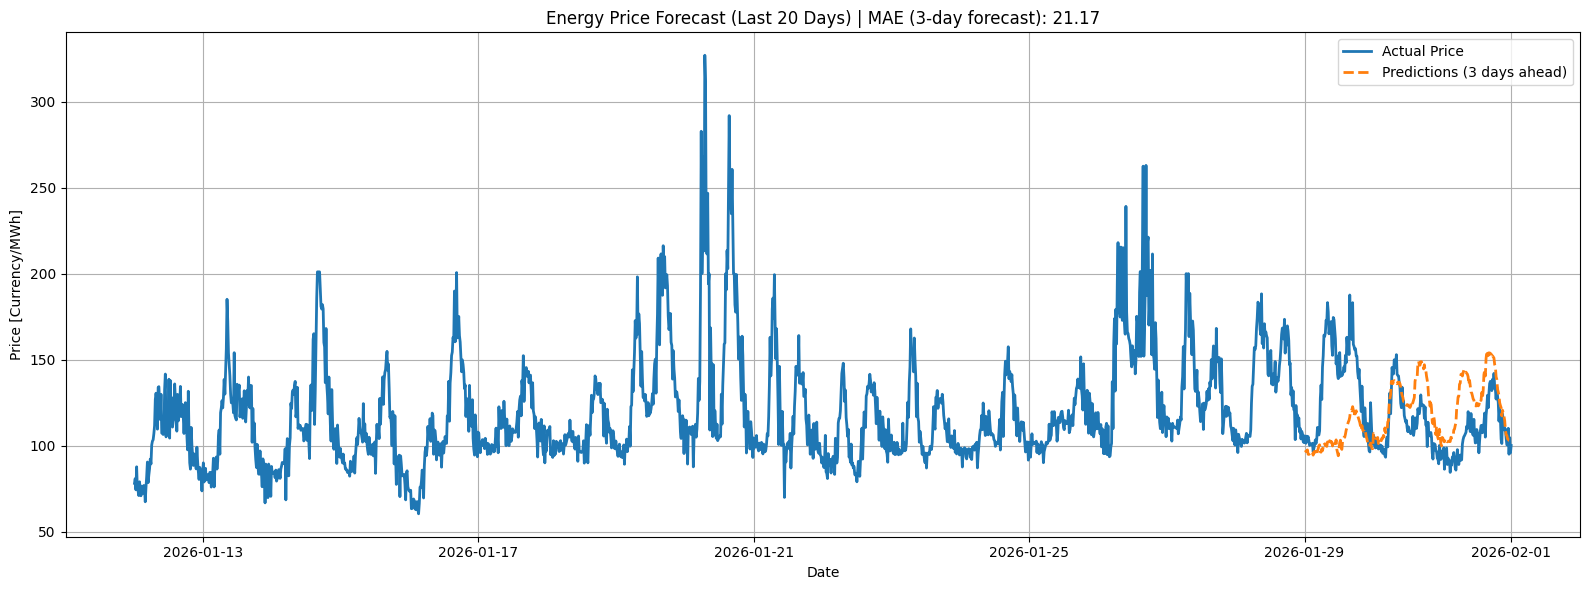

In [67]:
# ---------------------------
# 2. Define target + features
# ---------------------------

# Define target (3 days ahead = 288 steps)
target = 'target_288'

# Drop non-feature columns
columns_to_drop = ["price", "target_288", "regime",'datetime_utc']

X = model_12m.drop(columns=columns_to_drop)
y = model_12m[target]
y_regime = model_12m['regime']

# ---------------------------
# 3. Train / Test split
# ---------------------------

# Last 3 days = 288 timesteps
forecast_horizon = 288

X_train = X.iloc[:-forecast_horizon]
y_train = y.iloc[:-forecast_horizon]

X_test = X.iloc[-forecast_horizon:]
y_test = y.iloc[-forecast_horizon:]

# ---------------------------
# 4. Train final model
# ---------------------------

#Model
# ── 1. Regime Classifier ──────────────────────────────────────────────────────
weights = compute_sample_weight(class_weight="balanced", y=y_regime_train)
clf = XGBClassifier(objective="multi:softprob", num_class=3)
clf.fit(X_train, y_regime_train, sample_weight=weights)

# ── 2. Regime-specific XGBoost Regressors ─────────────────────────────────────
xgb_params = dict(
    n_estimators=300, learning_rate=0.01, max_depth=6,
    subsample=1.0, colsample_bytree=0.7, random_state=42,
    reg_lambda=5, reg_alpha=0.1, gamma=0
)
model_normal = XGBRegressor(**xgb_params)
model_pos    = XGBRegressor(**xgb_params)
model_neg    = XGBRegressor(**xgb_params)

# Train only on recent data for positive spikes (last ~24k samples)
recent_mask = X_train.index > (len(X_train) - 24000)
model_normal.fit(X_train[y_regime_train == 0], y_train[y_regime_train == 0])
model_pos.fit(X_train[(y_regime_train == 1) & recent_mask], y_train[(y_regime_train == 1) & recent_mask])
model_neg.fit(X_train[y_regime_train == 2], y_train[y_regime_train == 2])


# ── 3. Regime-blended predictions with GARCH amplitude correction ─────────────
probs    = clf.predict_proba(X_test)
p_normal = probs[:, 0]
p_pos    = probs[:, 1]
p_neg    = probs[:, 2]

y_pred_soft = (
    p_neg    * model_neg.predict(X_test)    * 0.85 +
    p_normal * model_normal.predict(X_test)  +
    p_pos    * model_pos.predict(X_test)    * 0.9
)



results = pd.DataFrame({
    "DateTime": model_12m['datetime_utc'].iloc[-forecast_horizon:],
    "Actual_Price": model_12m['price'].iloc[-forecast_horizon:],
    "Predicted_Price": y_pred_soft
})
results["DateTime_shifted"] = results["DateTime"] - pd.Timedelta(days=3)

# ---------------------------
# Compute MAE
# ---------------------------

mae = mean_absolute_error(results["Actual_Price"], results["Predicted_Price"])

# ---------------------------
# 7. Plot last 20 days
# ---------------------------

# 20 days = 20 * 96 timesteps
plot_horizon = 20 * 96

plot_data = model_12m.iloc[-plot_horizon:].copy()

plt.figure(figsize=(16, 6))

# Actual prices
plt.plot(
    plot_data['datetime_utc'],
    plot_data['price'],
    label='Actual Price',
    linewidth=2
)

# Predictions (only last 3 days)
plt.plot(
    results['DateTime'],
    results['Predicted_Price'],
    label='Predictions (3 days ahead)',
    linestyle='--',
    linewidth=2
)

# Predictions (shifted)
# plt.plot(
#     results['DateTime_shifted'],
#     results['Predicted_Price'],
#     label='Predictions (made 3 days earlier)',
#     linestyle='--',
#     linewidth=2
# )

plt.title(f'Energy Price Forecast (Last 20 Days) | MAE (3-day forecast): {mae:.2f}')
plt.xlabel('Date')
plt.ylabel('Price [Currency/MWh]')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### beginning of December spikes (1st of December)

In [68]:
start_date = "2025-02-01 00:00:00"
end_date  = "2025-12-05 00:00:00"
model_12m['datetime_utc'] =  pd.to_datetime(model_12m['datetime_utc'], format="%Y-%m-%d %H:%M:%S")
model_12m = model_12m[(model_12m['datetime_utc'] >= start_date) & (model_12m['datetime_utc'] <= end_date)]

/var/folders/sj/pc75w_ds6w72_p6qqgqy9m980000gn/T/ipykernel_16299/2545262576.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  model_12m['datetime_utc'] =  pd.to_datetime(model_12m['datetime_utc'], format="%Y-%m-%d %H:%M:%S")


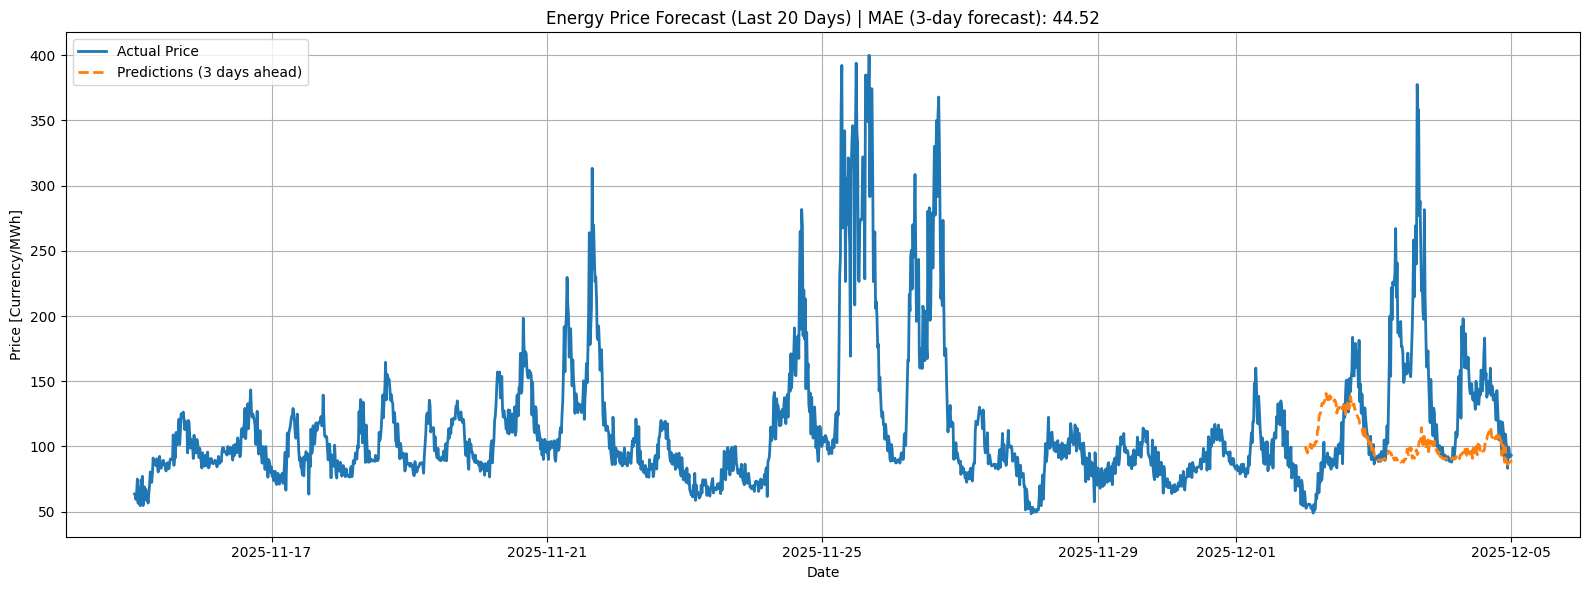

In [71]:
# ---------------------------
# 2. Define target + features
# ---------------------------

# Define target (3 days ahead = 288 steps)
target = 'target_288'

# Drop non-feature columns
columns_to_drop = ["price", "target_288", "regime",'datetime_utc']

X = model_12m.drop(columns=columns_to_drop)
y = model_12m[target]
y_regime = model_12m['regime']

# ---------------------------
# 3. Train / Test split
# ---------------------------

# Last 3 days = 288 timesteps
forecast_horizon = 288

X_train = X.iloc[:-forecast_horizon]
y_train = y.iloc[:-forecast_horizon]

X_test = X.iloc[-forecast_horizon:]
y_test = y.iloc[-forecast_horizon:]

# ---------------------------
# 4. Train final model
# ---------------------------

#Model
# ── 1. Regime Classifier ──────────────────────────────────────────────────────
weights = compute_sample_weight(class_weight="balanced", y=y_regime_train)
clf = XGBClassifier(objective="multi:softprob", num_class=3)
clf.fit(X_train, y_regime_train, sample_weight=weights)

# ── 2. Regime-specific XGBoost Regressors ─────────────────────────────────────
xgb_params = dict(
    n_estimators=300, learning_rate=0.01, max_depth=6,
    subsample=1.0, colsample_bytree=0.7, random_state=42,
    reg_lambda=5, reg_alpha=0.1, gamma=0
)
model_normal = XGBRegressor(**xgb_params)
model_pos    = XGBRegressor(**xgb_params)
model_neg    = XGBRegressor(**xgb_params)

# Train only on recent data for positive spikes (last ~24k samples)
recent_mask = X_train.index > (len(X_train) - 24000)
model_normal.fit(X_train[y_regime_train == 0], y_train[y_regime_train == 0])
model_pos.fit(X_train[(y_regime_train == 1) & recent_mask], y_train[(y_regime_train == 1) & recent_mask])
model_neg.fit(X_train[y_regime_train == 2], y_train[y_regime_train == 2])


# ── 3. Regime-blended predictions with GARCH amplitude correction ─────────────
probs    = clf.predict_proba(X_test)
p_normal = probs[:, 0]
p_pos    = probs[:, 1]
p_neg    = probs[:, 2]

y_pred_soft = (
    p_neg    * model_neg.predict(X_test)    * 0.85 +
    p_normal * model_normal.predict(X_test)  +
    p_pos    * model_pos.predict(X_test)    * 0.9
)



results = pd.DataFrame({
    "DateTime": model_12m['datetime_utc'].iloc[-forecast_horizon:],
    "Actual_Price": model_12m['price'].iloc[-forecast_horizon:],
    "Predicted_Price": y_pred_soft
})
results["DateTime_shifted"] = results["DateTime"] - pd.Timedelta(days=3)

# ---------------------------
# Compute MAE
# ---------------------------

mae = mean_absolute_error(results["Actual_Price"], results["Predicted_Price"])

# ---------------------------
# 7. Plot last 20 days
# ---------------------------

# 20 days = 20 * 96 timesteps
plot_horizon = 20 * 96

plot_data = model_12m.iloc[-plot_horizon:].copy()

plt.figure(figsize=(16, 6))

# Actual prices
plt.plot(
    plot_data['datetime_utc'],
    plot_data['price'],
    label='Actual Price',
    linewidth=2
)

# Predictions (only last 3 days)
plt.plot(
    results['DateTime'],
    results['Predicted_Price'],
    label='Predictions (3 days ahead)',
    linestyle='--',
    linewidth=2
)

# Predictions (shifted)
# plt.plot(
#     results['DateTime_shifted'],
#     results['Predicted_Price'],
#     label='Predictions (made 3 days earlier)',
#     linestyle='--',
#     linewidth=2
# )

plt.title(f'Energy Price Forecast (Last 20 Days) | MAE (3-day forecast): {mae:.2f}')
plt.xlabel('Date')
plt.ylabel('Price [Currency/MWh]')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Testing MAE on 1 day

### 1. Grid search

In [71]:
model_12m['target_96'] = model_12m["price"].shift(-96)

/var/folders/sj/pc75w_ds6w72_p6qqgqy9m980000gn/T/ipykernel_22188/307889282.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  model_12m['target_96'] = model_12m["price"].shift(-96)


In [ ]:
#OPTUNA
import optuna
# ---------------------------
# 1. Prepare data
# ---------------------------

target = "target_96"

drop_cols = [
    "datetime_utc",
    "price",
    "target_288",
    target
]

X = model_12m.drop(columns=drop_cols)
y = model_12m[target]

# assume regime labels already exist in model_12m
y_regime = model_12m["regime"]  # <- must exist (0=normal,1=pos,2=neg)

tscv = TimeSeriesSplit(n_splits=5)

# ---------------------------
# 2. Optuna objective
# ---------------------------

def objective(trial):

    # ---- shared regressor params ----
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 800),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "subsample": trial.suggest_float("subsample", 0.7, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "gamma": trial.suggest_float("gamma", 0.0, 0.3),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 1.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 1.0, 10.0),
        "random_state": 42,
        "tree_method": "hist"
    }

    # blending weights also tuned
    w_pos = trial.suggest_float("w_pos", 0.7, 1.0)
    w_neg = trial.suggest_float("w_neg", 0.7, 1.0)

    maes = []

    for train_idx, test_idx in tscv.split(X):

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        r_train = y_regime.iloc[train_idx]

        # ---- classifier ----
        weights = compute_sample_weight(class_weight="balanced", y=r_train)

        clf = XGBClassifier(
            objective="multi:softprob",
            num_class=3,
            n_estimators=200,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.9,
            colsample_bytree=0.9,
            random_state=42,
            tree_method="hist"
        )

        clf.fit(X_train, r_train, sample_weight=weights)

        # ---- regressors ----

        model_normal = XGBRegressor(**params)
        model_pos    = XGBRegressor(**params)
        model_neg    = XGBRegressor(**params)

        # masks
        recent_mask = X_train.index > (len(X_train) - 24000)

        model_normal.fit(X_train[r_train == 0], y_train[r_train == 0])

        if ((r_train == 1) & recent_mask).sum() > 50:
            model_pos.fit(X_train[(r_train == 1) & recent_mask],
                          y_train[(r_train == 1) & recent_mask])
        else:
            model_pos.fit(X_train[r_train == 1], y_train[r_train == 1])

        model_neg.fit(X_train[r_train == 2], y_train[r_train == 2])

        # ---- predictions ----
        probs = clf.predict_proba(X_test)

        p0, p1, p2 = probs[:, 0], probs[:, 1], probs[:, 2]

        pred = (
            p0 * model_normal.predict(X_test) +
            p1 * model_pos.predict(X_test) * w_pos +
            p2 * model_neg.predict(X_test) * w_neg
        )

        maes.append(mean_absolute_error(y_test, pred))

    return np.mean(maes)

# ---------------------------
# 3. Run Optuna
# ---------------------------


study = optuna.create_study(direction="minimize")

study.optimize(objective, n_trials=25, n_jobs=-1, show_progress_bar=True)  # increase to 100+



# ---------------------------
# 4. Results
# ---------------------------

print("\nBest MAE:", study.best_value)
print("\nBest Params:")
for k, v in study.best_params.items():
    print(f"{k}: {v}")

[I 2026-04-28 13:16:05,576] A new study created in memory with name: no-name-ff415ed6-2230-4b15-b010-23ab37353336
  0%|          | 0/25 [01:31<?, ?it/s]

[W 2026-04-28 13:17:37,391] Trial 2 failed with parameters: {'n_estimators': 278, 'max_depth': 3, 'learning_rate': 0.022249363152855736, 'subsample': 0.9002686477072803, 'colsample_bytree': 0.6546304917893931, 'gamma': 0.12273592147349754, 'reg_alpha': 0.6576246968501933, 'reg_lambda': 4.054693189618663, 'w_pos': 0.8893603022703996, 'w_neg': 0.9960196407772364} because of the following error: ValueError('Input contains NaN.').
Traceback (most recent call last):
  File "/Users/laurenzpfleiderer/.pyenv/versions/3.10.6/envs/grid-intelligence/lib/python3.10/site-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "/var/folders/sj/pc75w_ds6w72_p6qqgqy9m980000gn/T/ipykernel_22188/1994645278.py", line 103, in objective
    maes.append(mean_absolute_error(y_test, pred))
  File "/Users/laurenzpfleiderer/.pyenv/versions/3.10.6/envs/grid-intelligence/lib/python3.10/site-packages/sklearn/utils/_param_validation.py", line 218, in wrapper
    return 

  0%|          | 0/25 [01:34<?, ?it/s]


KeyboardInterrupt: 

[W 2026-04-28 13:17:55,761] Trial 8 failed with parameters: {'n_estimators': 276, 'max_depth': 4, 'learning_rate': 0.022896218348671414, 'subsample': 0.8235527541517281, 'colsample_bytree': 0.6277147082584624, 'gamma': 0.057776040309175, 'reg_alpha': 0.21068428287129182, 'reg_lambda': 3.7780393033825295, 'w_pos': 0.7255980870819707, 'w_neg': 0.7936740144833072} because of the following error: ValueError('Input contains NaN.').
Traceback (most recent call last):
  File "/Users/laurenzpfleiderer/.pyenv/versions/3.10.6/envs/grid-intelligence/lib/python3.10/site-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "/var/folders/sj/pc75w_ds6w72_p6qqgqy9m980000gn/T/ipykernel_22188/1994645278.py", line 103, in objective
    maes.append(mean_absolute_error(y_test, pred))
  File "/Users/laurenzpfleiderer/.pyenv/versions/3.10.6/envs/grid-intelligence/lib/python3.10/site-packages/sklearn/utils/_param_validation.py", line 218, in wrapper
    return 

In [65]:
#check

model_12m['datetime_utc'].max()

Timestamp('2026-02-01 00:00:00+0000', tz='UTC')

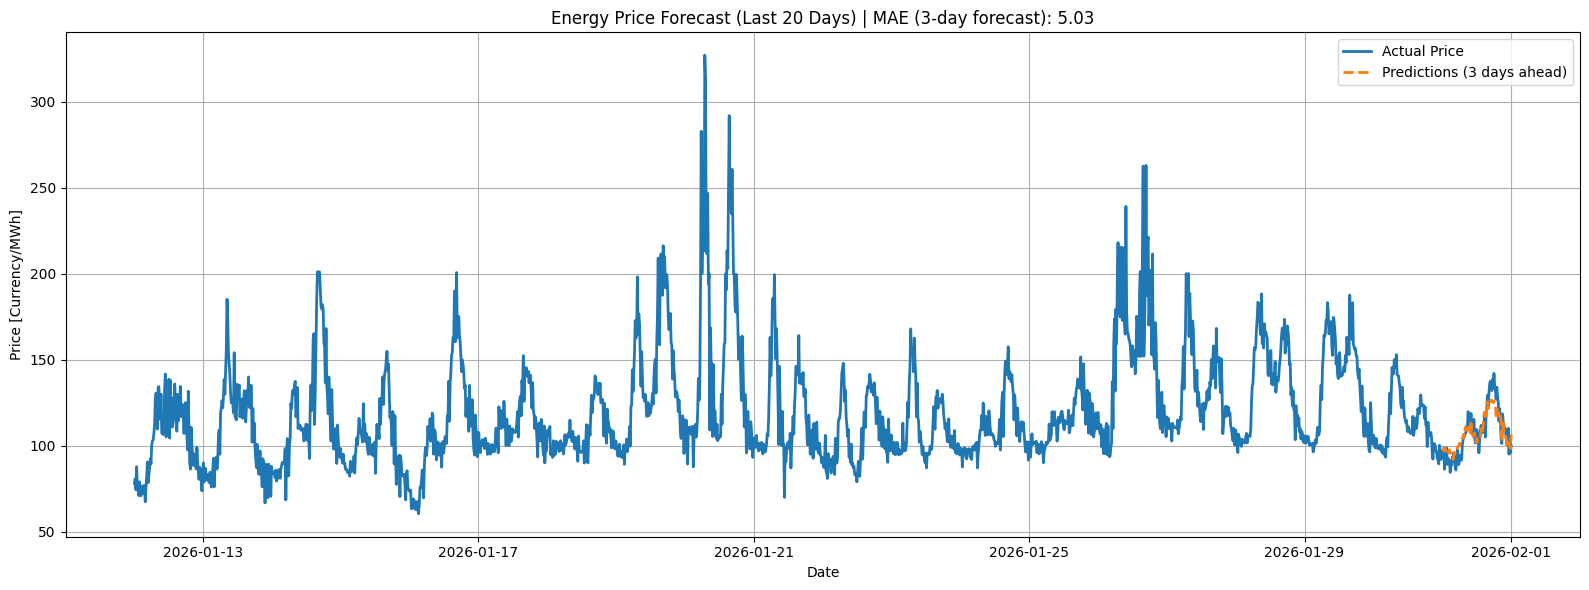

In [69]:
# ---------------------------
# 2. Define target + features
# ---------------------------

# Define target (3 days ahead = 288 steps)
target = 'target_96'

# Drop non-feature columns
columns_to_drop = ["price", "target_288","target_96", "regime",'datetime_utc']

X = model_12m.drop(columns=columns_to_drop)
y = model_12m[target]
y_regime = model_12m['regime']

# ---------------------------
# 3. Train / Test split
# ---------------------------

# Last 3 days = 288 timesteps
forecast_horizon = 96

X_train = X.iloc[:-forecast_horizon]
y_train = y.iloc[:-forecast_horizon]

X_test = X.iloc[-forecast_horizon:]
y_test = y.iloc[-forecast_horizon:]

# ---------------------------
# 4. Train final model
# ---------------------------

#Model
# ── 1. Regime Classifier ──────────────────────────────────────────────────────
weights = compute_sample_weight(class_weight="balanced", y=y_regime_train)
clf = XGBClassifier(objective="multi:softprob", num_class=3)
clf.fit(X_train, y_regime_train, sample_weight=weights)

# ── 2. Regime-specific XGBoost Regressors ─────────────────────────────────────
xgb_params = dict(
    n_estimators=300, learning_rate=0.01, max_depth=6,
    subsample=1.0, colsample_bytree=0.7, random_state=42,
    reg_lambda=5, reg_alpha=0.1, gamma=0
)
model_normal = XGBRegressor(**xgb_params)
model_pos    = XGBRegressor(**xgb_params)
model_neg    = XGBRegressor(**xgb_params)

# Train only on recent data for positive spikes (last ~24k samples)
recent_mask = X_train.index > (len(X_train) - 24000)
model_normal.fit(X_train[y_regime_train == 0], y_train[y_regime_train == 0])
model_pos.fit(X_train[(y_regime_train == 1) & recent_mask], y_train[(y_regime_train == 1) & recent_mask])
model_neg.fit(X_train[y_regime_train == 2], y_train[y_regime_train == 2])


# ── 3. Regime-blended predictions with GARCH amplitude correction ─────────────
probs    = clf.predict_proba(X_test)
p_normal = probs[:, 0]
p_pos    = probs[:, 1]
p_neg    = probs[:, 2]

y_pred_soft = (
    p_neg    * model_neg.predict(X_test)    * 0.85 +
    p_normal * model_normal.predict(X_test)  +
    p_pos    * model_pos.predict(X_test)    * 0.9
)



results = pd.DataFrame({
    "DateTime": model_12m['datetime_utc'].iloc[-forecast_horizon:],
    "Actual_Price": model_12m['price'].iloc[-forecast_horizon:],
    "Predicted_Price": y_pred_soft
})
results["DateTime_shifted"] = results["DateTime"] - pd.Timedelta(days=3)

# ---------------------------
# Compute MAE
# ---------------------------

mae = mean_absolute_error(results["Actual_Price"], results["Predicted_Price"])

# ---------------------------
# 7. Plot last 20 days
# ---------------------------

# 20 days = 20 * 96 timesteps
plot_horizon = 20 * 96

plot_data = model_12m.iloc[-plot_horizon:].copy()

plt.figure(figsize=(16, 6))

# Actual prices
plt.plot(
    plot_data['datetime_utc'],
    plot_data['price'],
    label='Actual Price',
    linewidth=2
)

# Predictions (only last 3 days)
plt.plot(
    results['DateTime'],
    results['Predicted_Price'],
    label='Predictions (3 days ahead)',
    linestyle='--',
    linewidth=2
)

# Predictions (shifted)
# plt.plot(
#     results['DateTime_shifted'],
#     results['Predicted_Price'],
#     label='Predictions (made 3 days earlier)',
#     linestyle='--',
#     linewidth=2
# )

plt.title(f'Energy Price Forecast (Last 20 Days) | MAE (3-day forecast): {mae:.2f}')
plt.xlabel('Date')
plt.ylabel('Price [Currency/MWh]')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()